<a href="https://colab.research.google.com/github/mohammedaslanshas/codomax-ds-internship/blob/main/Day9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Cleaning (from Day 7)
df = df.drop(columns=["Cabin"])
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop_duplicates()
df = df.reset_index(drop=True)

# Organizing (from Day 7)
df = df[["Name", "Age", "Sex", "Pclass", "Survived", "Fare", "Embarked"]]
df = df.rename(columns={"Sex": "Gender", "Pclass": "Ticketclass"})
df["Ticketclass"] = df["Ticketclass"].astype("category")
df["Survived"] = df["Survived"].astype(bool)

# Verify it matches Day 7/8's final state before moving on
print(df.shape)          # should be (891, 7)
print(df.isnull().sum()) # should be all 0
df.info()

(891, 7)
Name           0
Age            0
Gender         0
Ticketclass    0
Survived       0
Fare           0
Embarked       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Name         891 non-null    object  
 1   Age          891 non-null    float64 
 2   Gender       891 non-null    object  
 3   Ticketclass  891 non-null    category
 4   Survived     891 non-null    bool    
 5   Fare         891 non-null    float64 
 6   Embarked     891 non-null    object  
dtypes: bool(1), category(1), float64(2), object(3)
memory usage: 36.8+ KB


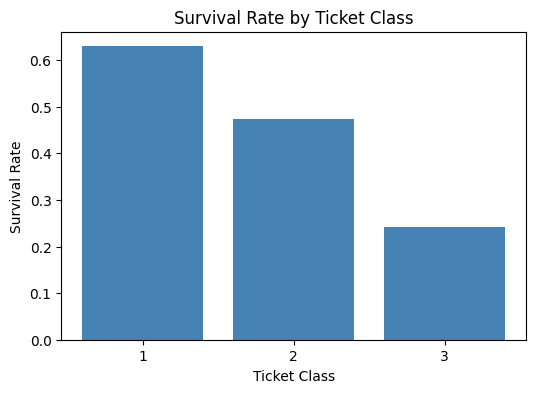

In [ ]:
#Bar Chart
survival_by_class = df.groupby("Ticketclass", observed=True)["Survived"].mean()

plt.figure(figsize=(6,4))
plt.bar(survival_by_class.index.astype(str), survival_by_class.values, color="steelblue")
plt.title("Survival Rate by Ticket Class")
plt.xlabel("Ticket Class")
plt.ylabel("Survival Rate")
plt.show()

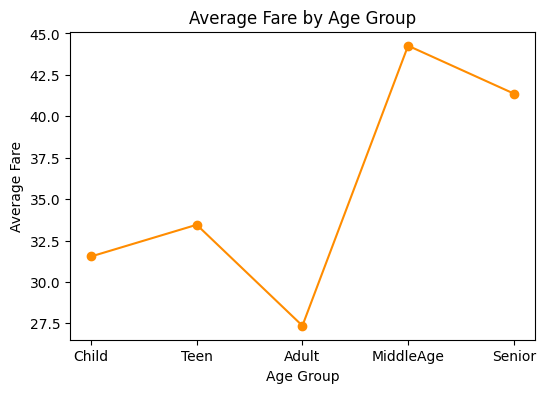

In [ ]:
#Line Chart
df["AgeGroup"] = pd.cut(df["Age"], bins=[0,12,18,35,60,80], labels=["Child","Teen","Adult","MiddleAge","Senior"])
avg_fare_by_age = df.groupby("AgeGroup", observed=True)["Fare"].mean()

plt.figure(figsize=(6,4))
plt.plot(avg_fare_by_age.index.astype(str), avg_fare_by_age.values, marker="o", color="darkorange")
plt.title("Average Fare by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Fare")
plt.show()

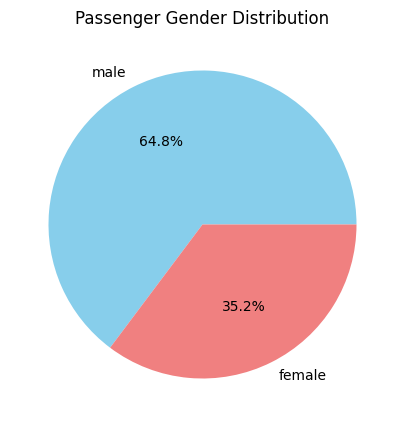

In [ ]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct="%1.1f%%", colors=["skyblue","lightcoral"])
plt.title("Passenger Gender Distribution")
plt.show()

Gender
female    0.742038
male      0.188908
Name: Survived, dtype: float64


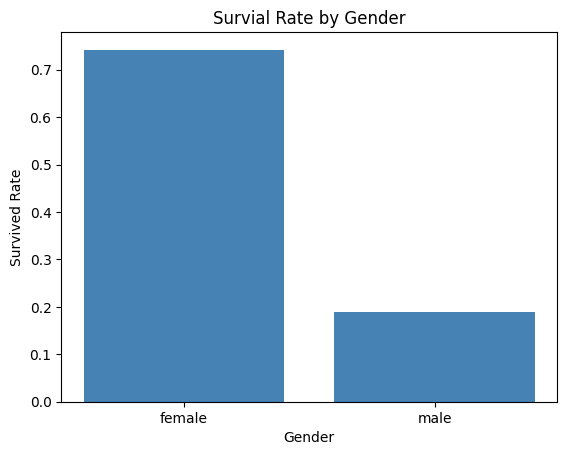

In [ ]:
survival_by_gender =df.groupby("Gender")["Survived"].mean()
print(survival_by_gender)
plt.figsize=(6,4)
plt.bar(survival_by_gender.index, survival_by_gender.values, color="Steelblue")
plt.title("Survial Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survived Rate")
plt.show()

In [ ]:
avg_age_by_class= df.groupby("Ticketclass",observed=True)["Age"].mean()
print(avg_age_by_class)

plt.figure(figsize=(6,4))
plt.plot(avg_age_by_class.index.astype(str), avg_age_by_class.values, marker="o", color="darkorange")
plt.title("Average Age by Ticket Class")
plt.xlabel("Ticket Class")
plt.ylabel("Average Age")
plt.show()

Ticketclass
1    36.812130
2    29.765380
3    25.932627
Name: Age, dtype: float64


Ticketclass
3    491
1    216
2    184
Name: count, dtype: int64


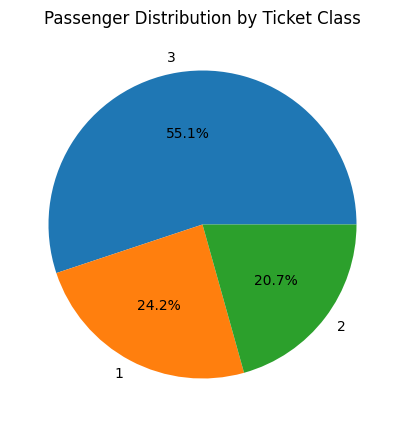

In [15]:
class_counts =df["Ticketclass"].value_counts()
print(class_counts)

plt.figure(figsize=(5,5))
plt.pie(class_counts.values, labels = class_counts.index.astype(str), autopct="%1.1f%%")
plt.title("Passenger Distribution by Ticket Class")
plt.show()